# Rossby-Kelvin mode figures from Nicolas & Vallis (2026): Mechanisms of Superrotation in Slowly-Rotating and Tidally-Locked Planets

Use this notebook to reproduce figures 4 from the paper.

In [1]:
# Set environment variables for best performance
%env OMP_NUM_THREADS=1
%env NUMEXPR_MAX_THREADS=1

import numpy as np
import xarray as xr
from scipy.integrate import cumulative_trapezoid

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs

import dedalus.public as d3

env: OMP_NUM_THREADS=1
env: NUMEXPR_MAX_THREADS=1


[iacmac-ds4973:39583] shmem: mmap: an error occurred while determining whether or not /var/folders/g5/y1nh4h6x3j3c3lh5frsdkvtc0000gq/T//ompi.iacmac-ds4973.503/jf.0/3388211200/sm_segment.iacmac-ds4973.503.c9f40000.0 could be created.


In [2]:
from emfcTools import calc_emfc_bvp
from plottingTools import plot_map, add_ticks

Rossby-Kelvin are obtained as solutions of an eigenvalue problem. We solve the EVP directly in this notebook. The following class is used to set up and solve the EVP

In [3]:
class EVP:
    def __init__(self, Ro_T, tau_rad_nondim, alpha, lat0, E = 0., stratification = 0.05 ,resolution = 64):
        """Two-level eigenvalue problems on the sphere, with background zonal wind from Zurita-Gotor and Held (2018). 
        Solves for the growth rates and structures of the most unstable modes.
        
        Parameters
        ----------
        Ro_T : float
            Thermal Rossby number
        tau_rad_nondim : float
            Non-dimensional radiative timescale
        alpha : float
            angular-momentum-conservation parameter for the background zonal wind
            (see Zurita-Gotor and Held 2018 and Nicolas and Vallis 2026, section 3.3)
        lat0 : float
            Latitude of jet maximum for the background zonal wind (degrees)
        E : float, optional
            Ekman number for low-level drag (default: 0, i.e. no drag)
        stratification : float, optional
            Stratification parameter, which controls the vertical structure of the forcing 
            (default: 0.05)
        resolution : int, optional
            Degree of spherical harmonic triangular truncation (default: 64). 
        """
        self.lat0 = lat0 * np.pi/180
        self.alpha = alpha
        self.Nphi = 2*resolution
        self.Ntheta = resolution

        self.Ro_T = Ro_T
        self.stratification = stratification
        self.E = E
        self.tau_rad_nondim = tau_rad_nondim

    def setup_bases(self):
        """Set up Dedalus bases and fields for the eigenvalue problem."""
        dealias = (3/2, 3/2)
        dtype = np.complex128
        
        self.coords = d3.S2Coordinates('phi', 'theta')
        self.dist = d3.Distributor(self.coords, dtype=dtype)
        self.full_basis = d3.SphereBasis(self.coords, (self.Nphi, self.Ntheta), radius=1, dealias=dealias, dtype=dtype)
        self.zonal_basis = d3.SphereBasis(self.coords, (1, self.Ntheta), radius=1, dealias=dealias, dtype=dtype)
    
    def setup_model(self):
        """Set up the eigenvalue problem in Dedalus."""
        kappa = 2/7
        self.P1 = 0.25**kappa
        self.P2 = 0.75**kappa

        hyperdiff_degree = 4; nu = 1.5e-7

        zcross = lambda A: d3.MulCosine(d3.skew(A))
        if hyperdiff_degree==4:
            hyperdiff = lambda A : nu*d3.lap(d3.lap(A))
        elif hyperdiff_degree==8:
            hyperdiff = lambda A : nu*d3.lap(d3.lap(d3.lap(d3.lap(A))))
        else:
            raise ValueError('hyperdiff_degree')
        
        # Fields
        u10      = self.dist.VectorField(self.coords, name='u10', bases=self.zonal_basis)
        u20      = self.dist.VectorField(self.coords, name='u20', bases=self.zonal_basis)
        u1       = self.dist.VectorField(self.coords, name='u1', bases=self.full_basis)
        u2       = self.dist.VectorField(self.coords, name='u2', bases=self.full_basis)
        Phi1     = self.dist.Field(name='Phi1'  , bases=self.full_basis)
        theta1   = self.dist.Field(name='theta1', bases=self.full_basis)
        theta2   = self.dist.Field(name='theta2', bases=self.full_basis)
        theta0 = self.dist.Field(name='theta0', bases=self.zonal_basis)
        tau1  = self.dist.Field(name='tau1')
        sigma = self.dist.Field(name='sigma')  # eigenvalue
        
        
        # Problem
        problem = d3.EVP([u1,u2,Phi1,theta1,theta2,tau1], eigenvalue=sigma, namespace=locals())
        problem.add_equation("sigma*u1 + hyperdiff(u1) + grad(Phi1) + zcross(u1) + self.Ro_T * ( u10@grad(u1) + u1@grad(u10) ) = 0")
        problem.add_equation("sigma*u2 + hyperdiff(u2) + grad(Phi1- (self.P2-self.P1)*(theta1+theta2)/2) + zcross(u2) + self.Ro_T * ( u20@grad(u2) + u2@grad(u20) ) + self.E * u2 = 0")
        problem.add_equation("sigma*theta1 + hyperdiff(theta1) + self.Ro_T * ( u1@grad(theta0) + u10@grad(theta1) - self.stratification * div(u2)/2 ) + theta1/self.tau_rad_nondim = 0")
        problem.add_equation("sigma*theta2 + hyperdiff(theta2) + self.Ro_T * ( u2@grad(theta0) + u20@grad(theta2) - self.stratification * div(u2)/2 ) + theta2/self.tau_rad_nondim = 0")
        problem.add_equation("div(u1+u2) + tau1 = 0")
        problem.add_equation("ave(Phi1) = 0");
        
        self.solver = problem.build_solver()

        self.u10  = u10
        self.u20  = u20
        self.u1   = u1  
        self.u2   = u2  
        self.Phi1 = Phi1
        self.theta1 = theta1
        self.theta2 = theta2
        self.theta0  = theta0

    def ZH_zetaa_u(self,lat):
        """Define the background zonal wind and vorticity profiles following Zurita-Gotor and Held (2018).

        Parameters
        ----------
        lat : array-like
            Latitudes (radians) at which to compute the background profiles

        Returns
        -------
        zetaa : array-like
            Background vorticity as a function of latitude
        u : array-like
            Background zonal wind as a function of latitude
        """
        f = np.sin(lat)
        lat0 = self.lat0
        alpha = self.alpha
        alpha2 = 1/np.cos(self.lat0)**2-alpha*np.tan(lat0)**2
        
        dlat = 5*np.pi/180
        step = lambda x: (np.tanh(-x)+1)/2
        zetaa = alpha * f * step((np.abs(lat)-lat0)/dlat) + alpha2 * f * step((-np.abs(lat)+lat0)/dlat)
        u = -cumulative_trapezoid((zetaa-f)*np.cos(lat),lat,initial=0)/np.cos(lat)
        
        return zetaa,u

    def initialize_basicstate(self):
        """Initialize the background zonal wind and potential temperature profiles for the eigenvalue problem."""
        _, theta = self.dist.local_grids(self.zonal_basis)
        _,u = self.ZH_zetaa_u(np.pi/2 - theta)

        u = u / self.Ro_T
        
        self.u10['g'][0] = u
        self.u20['g'][0] = u

        self.theta0['g'] = 0. # basic state potential temperature profile is barotropic

        #store latitude and wind for plotting
        self.lat_plot = ( np.pi/2 - theta[0] ) * 180 / np.pi
        self.u_plot = u[0]

    def solve_modes(self, zonal_wavenumbers, N_per_m):
        """
        Solve the eigenvalue problem for specified zonal wavenumbers and return the most unstable modes.

        Parameters
        ----------
        zonal_wavenumbers : array-like
            Zonal wavenumbers for which to solve the eigenvalue problem.
        N_per_m : int
            Number of modes per zonal wavenumber to return (returned in order of decreasing growth rate)
        """
        N_m = len(zonal_wavenumbers)
        self.growth_rates = np.zeros((N_m, N_per_m))
        self.frequencies  = np.zeros((N_m, N_per_m))
        self.phasespeeds  = np.zeros((N_m, N_per_m))
        
        phi, theta = self.dist.local_grids(self.full_basis)
        latitude = (np.pi / 2 - theta[0]) / np.pi * 180
        longitude = phi[:,0] / np.pi * 180  - 180
        
        skeleton = xr.DataArray(self.Phi1['g']**0,coords={'latitude':latitude,'longitude':longitude},dims=['longitude','latitude'])
        skeletonu = xr.DataArray(self.u1['g']**0,coords={'latitude':latitude,'longitude':longitude},dims=['component','longitude','latitude'])
        
        self.modes=[]
        for im,m in enumerate(zonal_wavenumbers):
            print("Computing modes, m=%i"%m)
            # Get all eigenvectors with zonal wavenumber m
            sp = self.solver.subproblems_by_group[(m, None)]
            self.solver.solve_dense(sp)
            eigens = self.solver.eigenvalues.real
            eigens[np.isinf(eigens)] = -1e10

            self.modes.append([])

            for n in range(1,N_per_m + 1):
                index = np.argsort(eigens)[-n]
                self.growth_rates[im,n-1] = eigens[index]
                self.frequencies [im,n-1] = -self.solver.eigenvalues.imag[index]
                self.phasespeeds [im,n-1] = self.frequencies[im,n-1]/m
                
                self.solver.set_state(index, sp.subsystems[0])
                for var in self.Phi1,self.theta1,self.theta2, self.u1, self.u2:
                    var.change_scales(1)
                Phi1_ = skeleton * self.Phi1['g']
                Phi2_ = skeleton * (self.Phi1['g']- (self.P2-self.P1)*(self.theta1['g']+self.theta2['g'])/2)
                u1_   = skeletonu * self.u1['g']
                u2_   = skeletonu * self.u2['g']
                omega = d3.div(self.u2).evaluate()
                vorticity_1 = ( -d3.div(d3.skew(self.u1)) ).evaluate()
                vorticity_2 = ( -d3.div(d3.skew(self.u2)) ).evaluate()

                omega.change_scales(1); vorticity_1.change_scales(1); vorticity_2.change_scales(1)
                omega_ = skeleton * omega['g']
                vorticity_1_ = skeleton * vorticity_1['g']
                vorticity_2_ = skeleton * vorticity_2['g']

                ds = xr.merge((u1_.rename('u1'),
                               u2_.rename('u2'),
                               Phi1_.rename('Phi1'),
                               Phi2_.rename('Phi2'),
                               omega_.rename('omega'),
                               vorticity_1_.rename('vorticity_1'),
                               vorticity_2_.rename('vorticity_2')
                              ))
                self.modes[-1].append(ds / np.abs(np.real(ds.Phi1)).max())


In [4]:
def get_params(EVP):
    """Get maximum background zonal wind, Froude number, 
    and deformation radius divided by latitude of jet maximum 
    for a given EVP instance."""
    Ro_T = EVP.Ro_T
    U_max = EVP.u_plot.max() 
    phi0 = EVP.lat0

    c = np.sqrt(0.12 * EVP.stratification / 2 / Ro_T)
    Fr = U_max / np.cos(phi0) / c
    L_D = np.sqrt(Ro_T * c)
    L_D_ov_phi0 = L_D/ phi0

    EVP.U_max = U_max
    EVP.Fr = Fr
    EVP.L_D_ov_phi0 = L_D_ov_phi0

In [5]:
n_max=5
EVP_1 = EVP(10., 200, 0., 50,resolution=128,stratification = 0.05)
EVP_2 = EVP(2.5 , 200, 0.5, 50,resolution=128,stratification = 0.05)

for EVP_ in EVP_1,EVP_2:
    EVP_.setup_bases()
    EVP_.setup_model()
    EVP_.initialize_basicstate()
    # Get modes for zonal wavenumber m=1
    EVP_.solve_modes([1],n_max)
    get_params(EVP_)

Computing modes, m=1
2026-03-13 15:52:57,994 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 1s, Remaining: 0s, Rate: 1.0e+00/s
Computing modes, m=1
2026-03-13 15:53:05,094 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 1s, Remaining: 0s, Rate: 1.0e+00/s


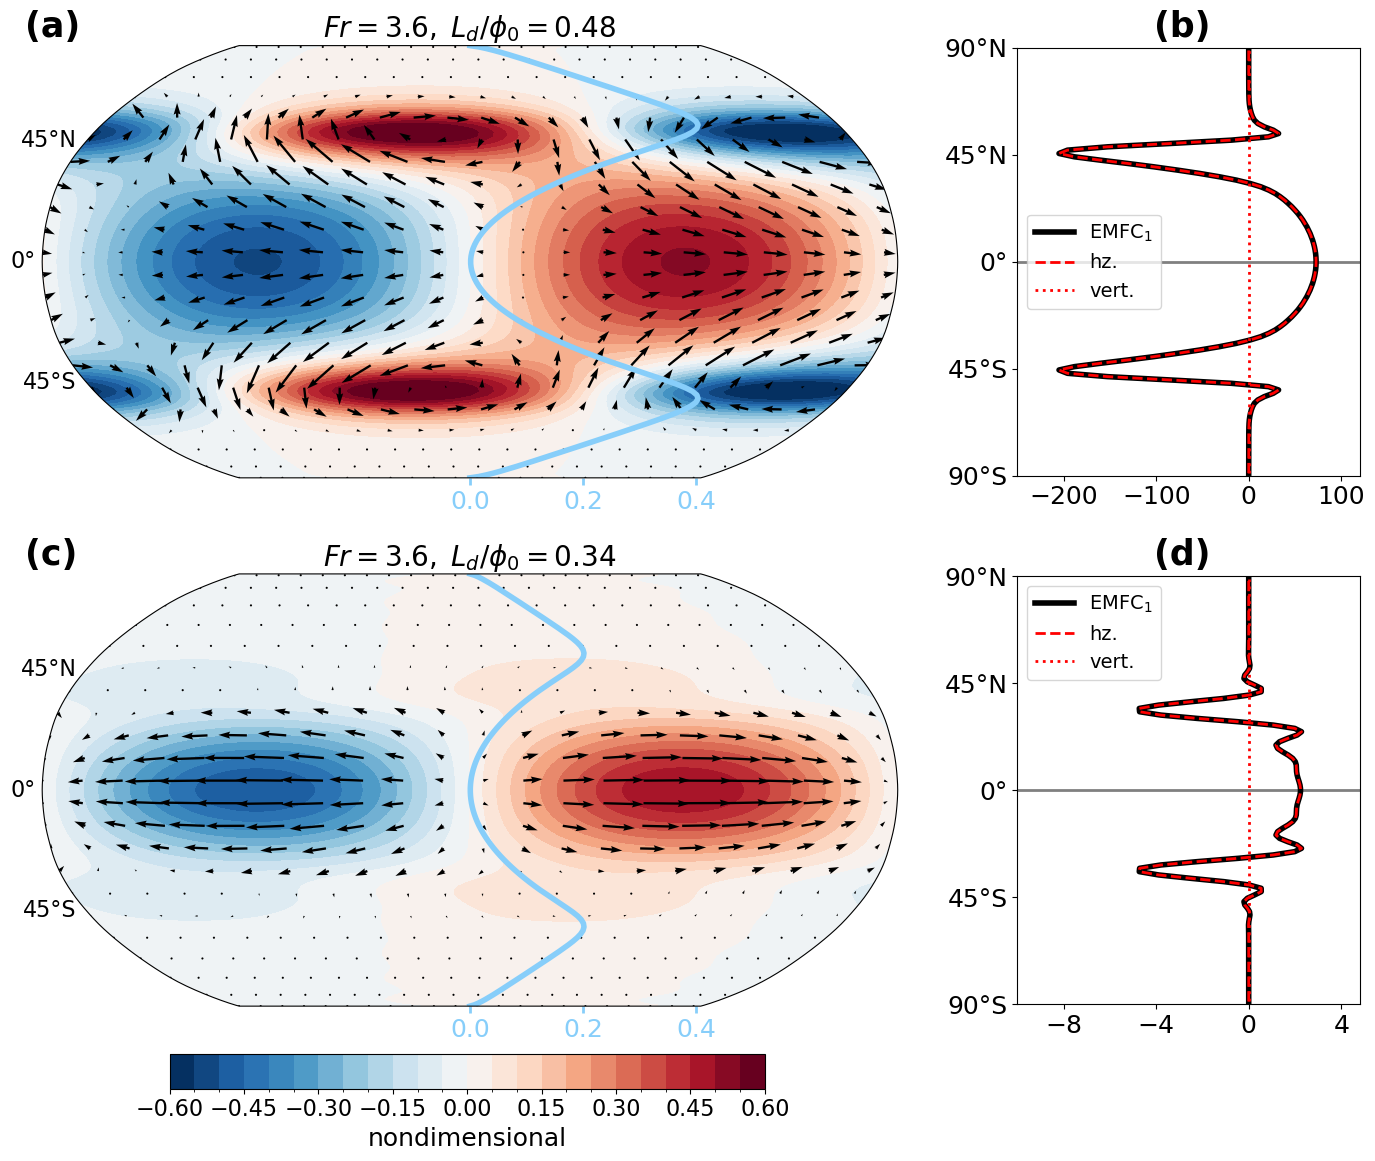

In [6]:
ftz=18
matplotlib.rcParams.update({'font.size':ftz})

fig = plt.figure(figsize=(17,14))
eps = 0.025
gs = gridspec.GridSpec(nrows=7, ncols=2, width_ratios=[1, 0.4], height_ratios = [eps,1,eps,eps,1,eps,0.05], figure=fig)
ax1 = fig.add_subplot(gs[0:3, 0], projection=ccrs.Robinson())
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[3:6, 0], projection=ccrs.Robinson())
ax4 = fig.add_subplot(gs[4, 1])
axcbar = fig.add_subplot([0.2,0.11,0.35,0.025]) #fig.add_subplot(gs[2, 0])
axs = [[ax1,ax2],[ax3,ax4]]


for i,(EVP_,mode_idx) in enumerate(zip((EVP_1,EVP_2),(0,4))): 
    # mode-idx hand-selects the RK mode 
    # For the first case, the RK mode is the most unstable mode, but not for the second case.

    mode = EVP_.modes[0][mode_idx] 
    dlon = mode.longitude[mode.Phi1.sel(latitude=slice(-5,5)).mean('latitude').argmax()] * np.pi / 180 - np.pi/2
    mode = np.real(EVP_.modes[0][mode_idx] * np.exp(1j * dlon))
    mean_KE = ((mode.u1**2).sum('component') * np.cos(mode.latitude * np.pi/180)).mean() / 2
    mode = mode / np.sqrt(mean_KE)  # non-dimensionalize by mean KE
    calc_emfc_bvp(mode,EVP_.Ro_T)

    ##### PLOT UPPER-LEVEL GEOPOTENTIAL AND WIND STRUCTURE OF THE MODE #####
    c = plot_map(axs[i][0],mode['Phi1'],mode['u1'],
                 vmin=None,vmax=None,levels=np.arange(-.6,.61,.05),cmap=plt.cm.RdBu_r,
                 wind_disc=6,quiver_kwargs={'scale':[80,80][i]},include_qk=False,
                 add_colorbar=False,
                 startlat=0)
    
    wind_clr = 'lightskyblue'
    # The background wind line is ajusted by hand for simplicity
    adjustment_factor = 275.
    axs[i][0].plot(EVP_.u_plot * adjustment_factor * EVP_.Ro_T, EVP_.lat_plot,linewidth=4,color=wind_clr,transform=ccrs.PlateCarree())
    add_ticks(axs[i][0],lons=[],lats=[-45,0,45],sz=16)
    axs[i][0].set_xticks(np.linspace(0.,900e4 ,3) )
    axs[i][0].tick_params(color=wind_clr,width=2,length=5)
    axs[i][0].set_xticklabels(np.linspace(0,0.4,3),color=wind_clr)
    axs[i][0].set_xlabel('')
    
    ##### PLOT EMFC OF THE MODE #####
    hz_clr = 'r'    
    axs[i][1].axhline(0.,color='gray',linewidth=2.)
    mode.emfc1.plot(ax = axs[i][1], y='latitude',color='k',linewidth=4,label='EMFC$_1$')
    (mode.emfc1 + mode.omegaubar).plot(ax = axs[i][1], y='latitude',color=hz_clr,linestyle='--',linewidth=2.,label='hz.')
    (-mode.omegaubar).plot(ax = axs[i][1], y='latitude',color=hz_clr,linestyle=':',linewidth=2.,label='vert.')

    scale = [1,0.04][i]
    axs[i][1].set_xlim(-250*scale,120*scale)
    axs[i][1].set_ylim(-90,90)
    axs[i][1].set_yticks(range(-90,91,45))
    axs[i][1].set_yticklabels(['90°S','45°S','0°','45°N','90°N'])
    axs[i][1].set_ylabel('')
    axs[i][1].set_xlabel('')
    axs[i][1].set_xticks(np.arange(-200,101,100)*scale)
    axs[i][1].legend(fontsize=14)

    axs[i][0].text(-0.02,1.02,["(a)","(c)"][i],fontweight='bold',fontsize=25,transform = axs[i][0].transAxes)
    axs[i][0].text(1.3,1.02,["(b)","(d)"][i],fontweight='bold',fontsize=25,transform = axs[i][0].transAxes)

cb = plt.colorbar(c, cax=axcbar, orientation = 'horizontal',label=r'nondimensional')
cb.ax.tick_params(labelsize=16)

for ax, EVP in zip((ax1,ax3),(EVP_1,EVP_2)):
    ax.set_title(r"$Fr = %.1f,\; L_d / \phi_0 = %.2f$"%(EVP.Fr,EVP.L_D_ov_phi0), fontsize = ftz+2)

# fig.savefig('eigenmodes.pdf',format='pdf',bbox_inches='tight')

